STEP 1: LOADING DATA

Original Data:
    StudentID           Name  Math  Science  English  Attendance
0           1       Ali Khan  78.0     85.0     90.0          92
1           2     Sara Ahmed  65.0      NaN     70.0          88
2           3  Bilal Hussain  90.0     95.0     88.0          95
3           4   Ayesha Tariq  45.0     50.0     60.0          70
4           5     Hamza Raza  88.0     79.0      NaN          85
5           6   Zainab Malik  72.0     68.0     75.0          80
6           7      Usman Ali  55.0     60.0     58.0          65
7           8    Fatima Noor  95.0     92.0     98.0          99
8           9     Ahmed Raza  38.0     42.0     40.0          55
9          10    Mariam Shah  80.0      NaN     82.0          90
10         11  Bilal Hussain  90.0     95.0     88.0          95
11         12   Hassan Iqbal  67.0     70.0     72.0          78
12         13    Noor Fatima  85.0     88.0     90.0          93
13         14     Saad Malik   NaN     55.0     60.0 

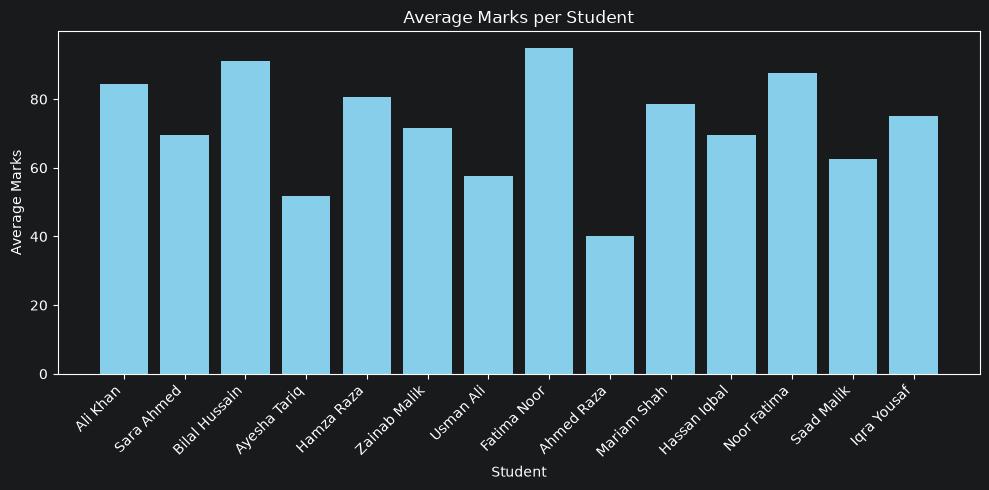

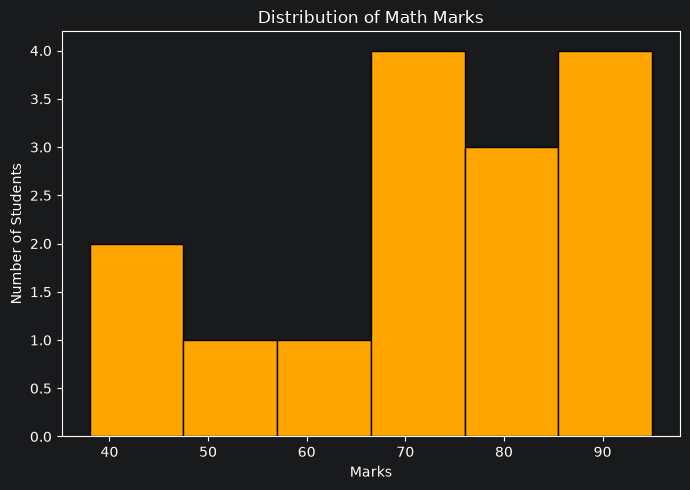

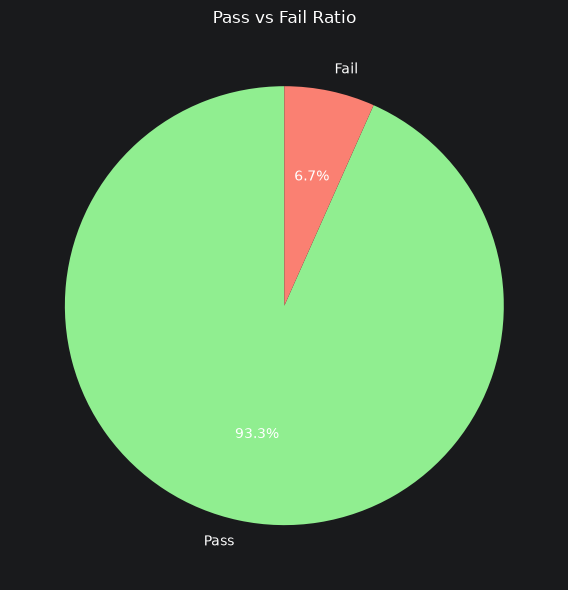

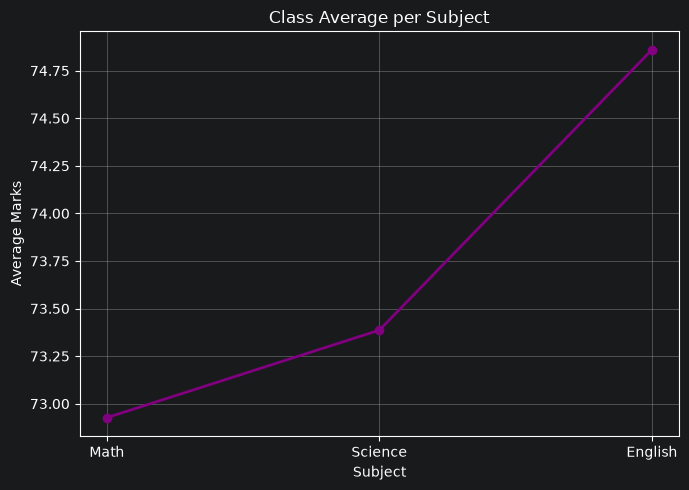


Cleaned data saved to 'students_cleaned.csv'

All done! Check the folder for chart images and cleaned CSV.


In [1]:
"""
====================================================
STUDENT PERFORMANCE ANALYZER
Week 1 Mini Project - Python for AI & Data Handling
====================================================
Yeh project sikhata hai:
- Pandas: data load karna, clean karna
- NumPy: numbers pe calculations (mean, median, etc.)
- Matplotlib: graphs/charts banana
"""

# -------------------------------------------------
# IMPORTS - Yeh libraries hain jo hum use karenge
# -------------------------------------------------

# pandas: data ko table (rows/columns) ki shape mein handle karne ke liye
# "as pd" matlab ab hum pandas ko sirf "pd" likh ke bula sakte hain (shortcut)
import pandas as pd

# numpy: numbers/math calculations ke liye (mean, median, std dev, etc.)
# "as np" matlab numpy ko "np" likh ke bula sakte hain
import numpy as np

# matplotlib.pyplot: graphs/charts banane ke liye
# "as plt" matlab isko "plt" likh ke bula sakte hain
import matplotlib.pyplot as plt


# =================================================
# STEP 1: DATA LOAD KARNA
# =================================================
# Yahan hum apni CSV file ko Python mein laa rahe hain

print("=" * 50)   # 50 baar "=" print karega, sirf design ke liye (==========)
print("STEP 1: LOADING DATA")
print("=" * 50)

# pd.read_csv() function CSV file ko padh kar usay
# "DataFrame" naam ki cheez mein convert karta hai.
# DataFrame = Excel jaisi table (rows aur columns)
# df = humne ye table ek variable mein store kar li, naam "df" rakha (data frame ka short form)
df = pd.read_csv("students.csv")

# Pura data print kar ke dekhte hain
print("\nOriginal Data:")   # \n matlab ek empty line chhod do (naya line start)
print(df)

# df.shape batata hai (kitni rows, kitne columns) - ek tuple (rows, columns) return karta hai
print(f"\nShape of data (rows, columns): {df.shape}")

# df.columns saari column names deta hai, list() us ko Python list mein convert kar deta hai
print(f"\nColumn names: {list(df.columns)}")


# =================================================
# STEP 2: DATA CLEANING
# =================================================
# Real-world data kabhi perfect nahi hota - missing values, duplicates hote hain
# Isliye hume pehle data ko "clean" karna padta hai

print("\n" + "=" * 50)
print("STEP 2: DATA CLEANING")
print("=" * 50)

# --- Missing values check karna ---
# df.isnull() har cell ko check karta hai: True agar khali (NaN) hai, False agar value hai
# .sum() har column ke True values ko count kar deta hai (kitni missing values hain)
print("\nMissing values in each column:")
print(df.isnull().sum())

# --- Duplicate rows check karna ---
# df.duplicated() har row ko check karta hai ke wo kisi pichli row jaisi hai ya nahi
# .sum() batata hai kitni duplicate rows hain
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# --- Duplicate rows hatana ---
# drop_duplicates() saari duplicate rows hata deta hai, sirf ek copy rakhta hai
# Hum result ko wapis df mein store kar rahe hain (overwrite kar rahe hain)
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

# --- Missing values fill karna (Math, Science, English, Attendance) ---
# Hum un columns ki list bana rahe hain jin mein numbers hain (text columns ko chhod kar)
numeric_cols = ["Math", "Science", "English", "Attendance"]

# Ek loop chalate hain har numeric column pe
for col in numeric_cols:
    # us column ka average (mean) nikalo - NaN khud-ba-khud ignore ho jate hain mean() mein
    mean_val = df[col].mean()

    # fillna() function jahan jahan NaN (khali value) hai, wahan ye mean_val daal deta hai
    # round(mean_val, 1) matlab average ko 1 decimal tak round kar diya (e.g. 73.4)
    df[col] = df[col].fillna(round(mean_val, 1))

# Ab cleaned data print karte hain
print("\nData after cleaning (missing values filled, duplicates removed):")
print(df)


# =================================================
# STEP 3: ANALYSIS - Naye columns banana
# =================================================
# Ab hum raw marks se kuch useful information nikalenge:
# Total marks, Average marks, aur Pass/Fail status

print("\n" + "=" * 50)
print("STEP 3: ANALYSIS")
print("=" * 50)

# --- Total marks nikalna ---
# df[["Math","Science","English"]] -> teen columns select kar rahe hain (double brackets!)
# .sum(axis=1) -> axis=1 matlab "row-wise" sum (har student ka apna total)
#                 (axis=0 hota to column-wise sum hota, jo galat hai humare liye)
df["Total"] = df[["Math", "Science", "English"]].sum(axis=1)

# --- Average marks nikalna ---
# .mean(axis=1) -> har row (student) ka average nikal rahe hain
# np.round(..., 2) -> NumPy ka round function, 2 decimal places tak round karta hai
df["Average"] = np.round(df[["Math", "Science", "English"]].mean(axis=1), 2)

# --- Pass/Fail status lagana ---
# np.where(condition, value_if_true, value_if_false)
# Agar Average >= 50 hai to "Pass" likho, warna "Fail" likho
df["Status"] = np.where(df["Average"] >= 50, "Pass", "Fail")

# Sirf important columns dikhana (pura df nahi, taake readable rahe)
print("\nData with Total, Average, and Status:")
print(df[["Name", "Math", "Science", "English", "Total", "Average", "Status"]])

# --- Topper (sab se zyada average wala student) dhundna ---
# df["Average"].idxmax() us row ka INDEX number deta hai jahan Average sab se zyada hai
# df.loc[index] us specific row ko nikal deta hai (saari information us row ki)
topper = df.loc[df["Average"].idxmax()]
print(f"\nTop performer: {topper['Name']} with average {topper['Average']}")

# --- Pass/Fail kitne students hain, count karna ---
# value_counts() har unique value ("Pass" / "Fail") ko count karta hai
print("\nPass/Fail Count:")
print(df["Status"].value_counts())


# =================================================
# STEP 4: STATISTICS (NumPy se)
# =================================================
# Har subject ke liye basic statistics nikalenge:
# Mean (average), Median (beech ki value), Std Dev (spread), Max, Min

print("\n" + "=" * 50)
print("STEP 4: STATISTICS")
print("=" * 50)

# Loop teeno subjects pe chalega - ek ek karke
for subject in ["Math", "Science", "English"]:
    print(f"\n--- {subject} ---")

    # np.mean() -> average nikalta hai
    # :.2f matlab number ko 2 decimal points tak format karo (e.g. 72.93)
    print(f"Mean   : {np.mean(df[subject]):.2f}")

    # np.median() -> data ko sort karke beech ki value deta hai
    # (outliers se kam affect hota hai mean ke mukable)
    print(f"Median : {np.median(df[subject]):.2f}")

    # np.std() -> standard deviation, batata hai data kitna "spread out" hai
    # zyada std dev = marks mein zyada farak (kuch bohot acha kuch bohot kharab)
    print(f"Std Dev: {np.std(df[subject]):.2f}")

    # np.max() / np.min() -> sab se zyada / sab se kam value
    print(f"Max    : {np.max(df[subject])}")
    print(f"Min    : {np.min(df[subject])}")


# =================================================
# STEP 5: VISUALIZATION (Matplotlib se graphs)
# =================================================
# Ab hum data ko 4 different graphs mein dikhayenge

print("\n" + "=" * 50)
print("STEP 5: VISUALIZATION")
print("=" * 50)
print("Generating charts... (they will pop up / save as images)")

# ---------- CHART 1: Bar Chart - Har student ka average ----------
plt.figure(figsize=(10, 5))     # naya blank chart banaya, size = 10 width x 5 height (inches)
plt.bar(df["Name"], df["Average"], color="skyblue")  # bar chart: x=names, y=averages
plt.xticks(rotation=45, ha="right")  # naam ke labels ko 45 degree tilt kiya (overlap na ho)
plt.title("Average Marks per Student")   # chart ka title
plt.xlabel("Student")     # x-axis ka label
plt.ylabel("Average Marks")  # y-axis ka label
plt.tight_layout()        # sab elements ko theek se fit karta hai (labels cut na hon)
plt.savefig("chart1_average_marks.png")  # chart ko image file ke tor pe save kiya
plt.show()                # chart ko screen pe dikhata hai (pop-up window mein)

# ---------- CHART 2: Histogram - Math marks ki distribution ----------
plt.figure(figsize=(7, 5))
# hist() data ko "bins" (groups) mein divide karta hai aur batata hai
# kitne students kis range mein aate hain (e.g. 0-20, 20-40, ...)
plt.hist(df["Math"], bins=6, color="orange", edgecolor="black")
plt.title("Distribution of Math Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("chart2_math_distribution.png")
plt.show()

# ---------- CHART 3: Pie Chart - Pass vs Fail ratio ----------
# Pehle Pass/Fail ki counts nikal li (kitne pass, kitne fail)
status_counts = df["Status"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    status_counts,                      # values jo pie chart mein dikhani hain
    labels=status_counts.index,         # labels = "Pass", "Fail"
    autopct="%1.1f%%",                  # percentage dikhao, 1 decimal ke sath (e.g. 93.3%)
    colors=["lightgreen", "salmon"],    # colors: pass=green, fail=red
    startangle=90                       # chart 90 degree se start hoga (upar se)
)
plt.title("Pass vs Fail Ratio")
plt.tight_layout()
plt.savefig("chart3_pass_fail.png")
plt.show()

# ---------- CHART 4: Line Chart - Subject-wise class average ----------
# Teeno subjects ka class average ek list mein nikal liya
subject_avg = [df["Math"].mean(), df["Science"].mean(), df["English"].mean()]

plt.figure(figsize=(7, 5))
plt.plot(
    ["Math", "Science", "English"],   # x-axis: subject names
    subject_avg,                      # y-axis: unke averages
    marker="o",                       # har point pe ek circle dot dikhao
    color="purple",
    linewidth=2                       # line ki thickness
)
plt.title("Class Average per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Marks")
plt.grid(True)              # background mein grid lines dikhao (easy to read)
plt.tight_layout()
plt.savefig("chart4_subject_average.png")
plt.show()


# =================================================
# STEP 6: CLEANED DATA SAVE KARNA
# =================================================
# Aakhir mein, hum apna cleaned + analyzed data wapis ek nayi CSV file mein save kar rahe hain
# index=False matlab row numbers (0,1,2...) ko CSV mein save nahi karna

df.to_csv("students_cleaned.csv", index=False)

print("\nCleaned data saved to 'students_cleaned.csv'")
print("\nAll done! Check the folder for chart images and cleaned CSV.")
